# Bài tập buổi 7 — Classification

- Bài 1: Titanic Dataset - Logistic Regression và so sánh với Linear Regression.
- Bài 2: Dry Bean Dataset - Logistic Regression và KNN.

## 0. Chuẩn bị môi trường & Import Thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Bài 1: Titanic Dataset

Sử dụng lại bộ dữ liệu **Titanic** trong bài tập về nhà trước.

### Yêu cầu

1. Sử dụng **Logistic Regression** để dự đoán hành khách sống sót hay không.
2. Sử dụng cùng cách chia dữ liệu train/test như bài tập trước nếu có thể.
3. Đánh giá kết quả của mô hình Logistic Regression.
4. So sánh kết quả của **Logistic Regression** với kết quả của **Linear Regression** trong bài tập trước.

### Nội dung so sánh

Có thể so sánh dựa trên các chỉ số:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Đưa ra nhận xét về mô hình phù hợp hơn đối với bài toán phân loại hành khách sống sót.

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409
1,Linear Regression,0.810056,0.786885,0.695652,0.738462


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Linear Regression Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



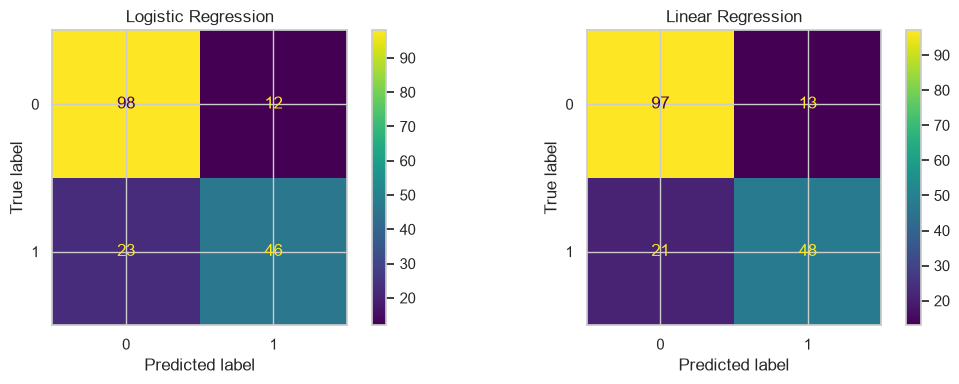

In [2]:
# Load dữ liệu
df = sns.load_dataset("titanic")

# Bỏ cột rò rỉ hoặc dư thừa
drop_cols = ["alive", "who", "adult_male", "class", "deck", "embark_town", "alone"]
drop_cols = [col for col in drop_cols if col in df.columns]
df = df.drop(columns=drop_cols)

# Tách X, y
X = df.drop(columns=["survived"])
y = df["survived"]

num_cols = ["pclass", "age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ]), num_cols),
    
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# Logistic Regression
log_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Linear Regression, ép output liên tục về 0/1
lin_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

lin_model.fit(X_train, y_train)
y_pred_lin_raw = lin_model.predict(X_test)
y_pred_lin = (y_pred_lin_raw >= 0.5).astype(int)

# So sánh metric
result_titanic = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_lin)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_lin)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_lin)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_lin)
    ]
})

display(result_titanic)

print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_log))

print("Linear Regression Report:")
print(classification_report(y_test, y_pred_lin))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0])
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lin, ax=axes[1])
axes[1].set_title("Linear Regression")

plt.tight_layout()
plt.show()

### Nhận xét:
- Logistic Regression phù hợp hơn Linear Regression vì `survived` là bài toán phân loại nhị phân 0/1.
- Linear Regression dự đoán giá trị liên tục nên phải dùng ngưỡng 0.5 để ép thành nhãn, cách này không tự nhiên bằng Logistic Regression.
- Do đó, Logistic Regression là mô hình phù hợp hơn đối với bài toán phân loại hành khách sống sót này.

## Bài 2: Dry Bean Dataset

Xây dựng mô hình phân loại các loại hạt trong bộ dữ liệu **Dry Bean Dataset** bằng hai thuật toán:

1. **Logistic Regression**
2. **K-Nearest Neighbors – KNN**

### Dữ liệu

Dữ liệu đã được preprocessing (file processing_seeds.ipynb) và chia thành hai tập:

```text
Dry_Bean_Dataset/
├── dry_bean_train.csv
└── dry_bean_test.csv
```

Train shape: (10834, 17)
Test shape: (2709, 17)


,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
0,69471,1069.638,399.100245,225.005782,1.773733,0.825923,71088,297.410868,0.707386,0.977254,0.763027,0.745203,0.005745,0.001093,0.555328,0.985004,CALI
1,82877,1162.581,391.817013,270.836144,1.446694,0.722634,84171,324.841921,0.825986,0.984627,0.770544,0.829065,0.004728,0.001378,0.687349,0.994384,BARBUNYA
2,65042,1023.506,419.202858,198.962774,2.106941,0.880190,65748,287.774298,0.783403,0.989262,0.780231,0.686480,0.006445,0.000883,0.471255,0.992906,HOROZ
3,41315,758.920,287.438268,183.447580,1.566869,0.769858,41704,229.355383,0.791930,0.990672,0.901417,0.797929,0.006957,0.001740,0.636691,0.997611,SIRA
4,91088,1168.645,459.300729,253.950486,1.808623,0.833243,91799,340.553731,0.789051,0.992255,0.838119,0.741461,0.005042,0.000940,0.549765,0.994318,CALI


Best KNN params: {'kneighborsclassifier__n_neighbors': 9}


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Logistic Regression,0.919158,0.930725,0.930049,0.930237
1,KNN,0.912883,0.927321,0.923602,0.925117


Logistic Regression Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709

KNN Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.87      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.92       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.94      0.94     

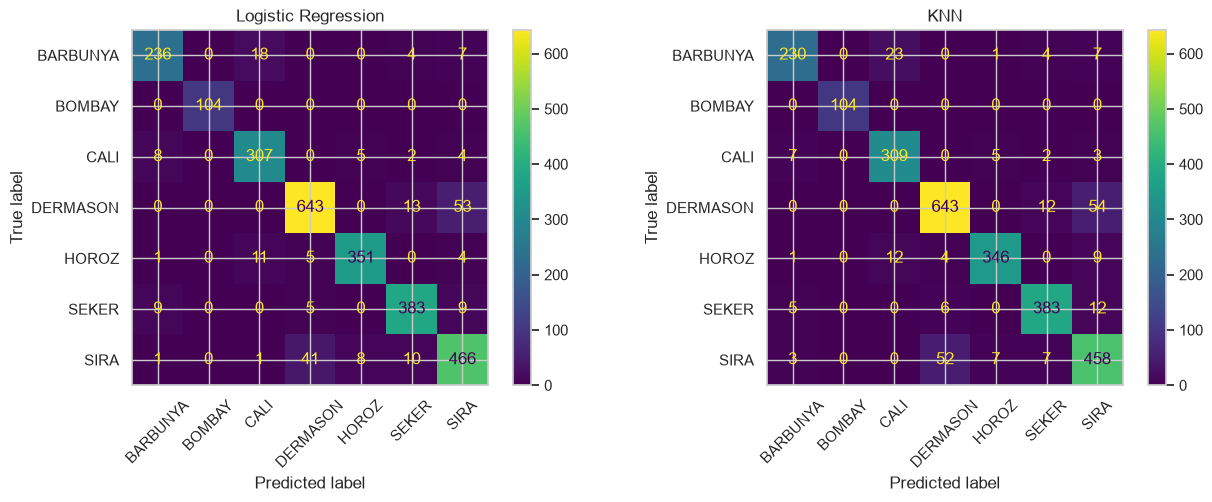

In [3]:
train_path = Path("Dry_Bean_Dataset") / "dry_bean_train.csv"
test_path = Path("Dry_Bean_Dataset") / "dry_bean_test.csv"

if train_path.exists() and test_path.exists():
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
else:
    excel_path = Path("Dry_Bean_Dataset.xlsx")
    if not excel_path.exists():
        excel_path = Path("Dry_Bean_Dataset") / "Dry_Bean_Dataset.xlsx"
        
    df_bean = pd.read_excel(excel_path)
    df_bean.columns = df_bean.columns.str.strip().str.lower()
    df_bean = df_bean.drop_duplicates()
    
    X = df_bean.drop(columns=["class"])
    y = df_bean["class"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    train_df = X_train.copy()
    train_df["class"] = y_train
    
    test_df = X_test.copy()
    test_df["class"] = y_test

train_df.columns = train_df.columns.str.strip().str.lower()
test_df.columns = test_df.columns.str.strip().str.lower()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())

# Tách X, y
target = "class"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

# Logistic Regression
log_bean = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=3000)
)

log_bean.fit(X_train, y_train)
y_pred_log_bean = log_bean.predict(X_test)

# KNN
knn_pipeline = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier()
)

param_grid = {
    "kneighborsclassifier__n_neighbors": [3, 5, 7, 9, 11]
}

knn_grid = GridSearchCV(
    knn_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5
)

knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test)

print("Best KNN params:", knn_grid.best_params_)

# So sánh
result_bean = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log_bean),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision_macro": [
        precision_score(y_test, y_pred_log_bean, average="macro"),
        precision_score(y_test, y_pred_knn, average="macro")
    ],
    "Recall_macro": [
        recall_score(y_test, y_pred_log_bean, average="macro"),
        recall_score(y_test, y_pred_knn, average="macro")
    ],
    "F1_macro": [
        f1_score(y_test, y_pred_log_bean, average="macro"),
        f1_score(y_test, y_pred_knn, average="macro")
    ]
})

display(result_bean)

print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_log_bean))

print("KNN Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log_bean,
    ax=axes[0],
    xticks_rotation=45
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    ax=axes[1],
    xticks_rotation=45
)
axes[1].set_title("KNN")

plt.tight_layout()
plt.show()

## Nhận xét Bài 2
- Cả Logistic Regression và KNN đều cho kết quả tốt, Accuracy đều trên 91%.  
- Logistic Regression tốt hơn một chút với Accuracy = 0.9192 và F1-macro = 0.9302, trong khi KNN đạt Accuracy = 0.9129 và F1-macro = 0.9251.  
- KNN chọn được tham số tốt nhất là `k = 9`, nhưng vẫn thấp hơn Logistic Regression.  
- Confusion Matrix cho thấy BOMBAY được phân loại rất tốt, còn DERMASON và SIRA bị nhầm lẫn với nhau nhiều hơn.  
- Do đó, Logistic Regression là mô hình nên ưu tiên cho Dry Bean Dataset.